In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report , confusion_matrix 

df=pd.read_csv("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

In [3]:
X=df.drop('Class',axis=1)
y=df['Class']


In [4]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42 
)

In [5]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)


In [6]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[56851    13]
 [   50    48]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.49      0.60        98

    accuracy                           1.00     56962
   macro avg       0.89      0.74      0.80     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [8]:
model=LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[54797  2067]
 [   10    88]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.90      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.93      0.53     56962
weighted avg       1.00      0.96      0.98     56962



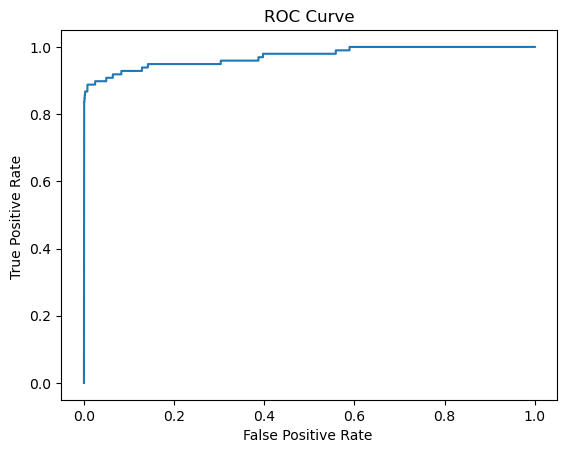

ROC AUC Score: 0.9718248265822931


In [12]:
from sklearn.metrics import roc_curve , roc_auc_score 
y_prob= model.predict_proba(X_test)[:,1]
fpr,tpr,tresholds =roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate ")
plt.ylabel("True Positive Rate ")
plt.title("ROC Curve")
plt.show()

print("ROC AUC Score:",roc_auc_score(y_test,y_prob))


Has a  97% discriminative power to distinguish between fraud and normal transactions.


In [13]:
from sklearn.metrics import precision_score , recall_score 

print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))


Precision: 0.04083526682134571
Recall: 0.8979591836734694
